In [1]:
import os
os.chdir(os.path.join(os.getcwd(), '..'))
os.getcwd()

'd:\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [2]:
from src.components.optuna_model_selection.lightning_modules import MRIModule

In [3]:
n = MRIModule([63,35,46])

In [4]:
import torch

In [5]:
n.get_img_masks(torch.ones((3,256,256))).shape

torch.Size([1, 3, 256, 256])

In [115]:
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from torchvision.transforms import v2
from src.components.optuna_model_selection.model import MRIFlexAttentionUNet, CorrectionModel
import cv2


from torch.utils.data import Dataset, DataLoader
class BaseModelDataset(Dataset):
    def __init__(self, mri_dir: Path, transform = None):
        
        files = sorted(file for file in mri_dir.iterdir())
        self.ds = [files[0], *files, files[-1]]
        self.transform = transform

    
    def __len__(self):

        return len(self.ds)-2

            

    def __getitem__(self, index): 
        
        img_0 = cv2.imread(self.ds[index], cv2.IMREAD_UNCHANGED)
        img_1 = cv2.imread(self.ds[index+1], cv2.IMREAD_UNCHANGED)
        img_2 = cv2.imread(self.ds[index+2], cv2.IMREAD_UNCHANGED)
        
        img = np.stack([img_0, img_1, img_2])
        min_img = img.min()
        max_img = img.max()
        img = (img - min_img)/(max_img - min_img + 1e-8)
        img = torch.from_numpy(img).to(torch.float32)

        
        if self.transform:
            img = self.transform(img)
           
        

        return img, index



class MRISegmentationModel:
    def __init__(self, config):


        self.device = config.device

        state_dict = torch.load('models/final/out/final_gpu-final/model-final-v2.ckpt',#config.base_model_path, 
                                'cpu', weights_only=False)['state_dict']
        inner_state_dict = {
            k[len("model."):]: v for k, v in state_dict.items() if k.startswith("model.")
        }
        
        hparams = torch.load(config.base_model_path, 'cpu', weights_only= False)['hyper_parameters']
        base_model = MRIFlexAttentionUNet(
            inp_channels=hparams['inp_channels'],
            first_conv_out_channels = hparams['first_conv_out_channels'],
            num_classes=3,
            depth = hparams['depth'],
            n_encoder_conv_layers = hparams['n_encoder_conv_layers'],
            n_decoder_conv_layers = hparams['n_decoder_conv_layers'],
            kernel_sizes = hparams['kernel_sizes']
        )
        base_model.load_state_dict(inner_state_dict)


        # state_dict = torch.load(config.correction_model_path, 
        #                         'cpu', weights_only=False)['state_dict']
        # inner_state_dict = {
        #     k[len("model."):]: v for k, v in state_dict.items() if k.startswith("model.")
        # }
        
        # hparams = torch.load(config.correction_model_path, 'cpu', weights_only= False)['hyper_parameters']
        # correction_model = CorrectionModel(
        #     inp_channels=hparams['inp_channels'],
        #     first_conv_out_channels = hparams['first_conv_out_channels'],
        #     num_classes=3,
        #     depth = hparams['depth'],
        #     n_encoder_conv_layers = hparams['n_encoder_conv_layers'],
        #     n_decoder_conv_layers = hparams['n_decoder_conv_layers'],
        #     kernel_sizes = hparams['kernel_sizes']
        # )

        # correction_model.load_state_dict(inner_state_dict)


        correction_model = CorrectionModel(
                    inp_channels=7,
                    first_conv_out_channels = 32,
                    num_classes=3,
                    depth = 3,
                    n_encoder_conv_layers = 2,
                    n_decoder_conv_layers = 2,
                    kernel_sizes = 3)

        self.base_model = base_model.to(self.device).eval()
        self.correction_model = correction_model.to(self.device).eval()

        if config.base_thresholds_path is not None:
            base_thresholds = np.load(config.base_thresholds_path)
        else:
            base_thresholds = np.array([0.5,0.5,0.5])

        if config.correction_thresholds_path is not None:
            correction_thresholds = np.load(config.correction_thresholds_path)
        else:
            correction_thresholds = np.array([0.5,0.5,0.5])

        self.base_thresholds = torch.as_tensor(base_thresholds, dtype=torch.float32, device=config.device).view(1, -1, 1, 1)
        self.correction_thresholds = torch.as_tensor(correction_thresholds, dtype=torch.float32, device=config.device).view(1, -1, 1, 1)


        self.config = config
        
        
    

    @torch.no_grad()
    def __call__(self, mri_dir):


        base_dataset = BaseModelDataset(mri_dir=mri_dir, transform=self.config.dev_transform)
        inp, _ = next(iter(base_dataset))
        self.out_shape = (3, inp.shape[1], inp.shape[2])
        self.len = len(base_dataset)
        self.base_dataloader = DataLoader(base_dataset, self.config.batch_size, False, num_workers=0)

        correction_imgs = []
        correction_inp_masks = []
        
        summed_masks = torch.zeros(self.out_shape, dtype = int, device = self.device)

        for inp, idx in self.base_dataloader:
            inp = inp.to(self.device)
            
            correction_imgs.append(inp[:,1].cpu())

            out = self.base_model(inp)
            probs = torch.sigmoid(out) 
            out = out.cpu().to(torch.float16)
            correction_inp_masks.append(out.to(torch.float16))

            summed_masks += (probs >= self.base_thresholds).int().sum(dim = 0)

    

        summed_masks = summed_masks.float() / torch.Tensor([74,61,45], device = self.device).view(3,1,1).float()
        summed_masks = summed_masks.unsqueeze(0).expand(self.config.batch_size, *self.out_shape)

        final_logits = []
        for imgs, masks in zip(correction_imgs, correction_inp_masks):
            imgs = imgs.to(self.device)
            masks = masks.to(self.device)
            print(imgs.shape, masks.shape, summed_masks.shape)
            logits = self.correction_model((imgs, masks, summed_masks))
            final_logits.append(logits)

        final_logits =torch.cat(final_logits, dim = 0)
        final_probs = torch.sigmoid(final_logits)
        final_masks = (final_probs >= self.correction_thresholds).bool().cpu()


        return final_masks, (torch.cat(correction_inp_masks, dim = 0) >= self.base_thresholds).bool()


NameError: name 'correction_inp_masks' is not defined

In [72]:
from src.entity.config_entity import MRISegmentationEntity


In [73]:
config = MRISegmentationEntity()

Benchmarking optimal batch size...
Batch size 16 is valid


In [116]:
modee = MRISegmentationModel(config)

In [100]:
torch.Tensor([1,2,3]).unsqueeze(0).expand(2,-1).unsqueeze(0).expand(2,2,3)

tensor([[[1., 2., 3.],
         [1., 2., 3.]],

        [[1., 2., 3.],
         [1., 2., 3.]]])

In [117]:
a, b = modee(Path('data/extracted_data/train/case2/case2_day1/scans'))

torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256]) torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])


In [121]:
a[1, ::1, ::1, ::1].shape

torch.Size([3, 256, 256])

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def visualize_3d_masks(
    masks,
    threshold=0.5,
    class_names=("Class 1", "Class 2", "Class 3"),
    figsize=(15, 6),
    step=1,
):
    """
    Visualize segmentation masks as 3D volumes.

    Parameters
    ----------
    masks : torch.Tensor or np.ndarray
        Shape:
            (N, H, W)       for a single binary mask
            (C, N, H, W)    for multiple binary masks
        N is the number of MRI slices.

    threshold : float
        Threshold for probability masks. Ignored for bool masks.

    class_names : tuple
        Names of the segmentation classes.

    step : int
        Spatial downsampling factor for faster visualization.
        Use 1 for full resolution, 2 or 4 for faster rendering.
    """
    if isinstance(masks, torch.Tensor):
        masks = masks.detach().cpu().numpy()

    masks = np.asarray(masks)

    if masks.ndim == 3:
        masks = masks[None, ...]  # (1, N, H, W)
    elif masks.ndim != 4:
        raise ValueError(
            f"Expected (N,H,W) or (C,N,H,W), got {masks.shape}"
        )

    # Convert probabilities to binary masks.
    if masks.dtype != np.bool_:
        masks = masks >= threshold
    else:
        masks = masks.copy()
    n_classes = masks.shape[0]
    colors = ["red", "limegreen", "dodgerblue", "orange", "magenta"]

    fig = plt.figure(figsize=figsize)
    if step == 0:
        volume = masks
    for c in range(n_classes):
        ax = fig.add_subplot(
            1, n_classes, c + 1, projection="3d"
        )
        if step == 0:
            volume = masks[c]
        else:
            volume = masks[c, ::step, ::step, ::step]

        if not volume.any():
            ax.set_title(
                f"{class_names[c] if c < len(class_names) else f'Class {c}'} (empty)"
            )
            ax.set_axis_off()
            continue

        ax.voxels(
            volume,
            facecolors=colors[c % len(colors)],
            edgecolor="none",
            shade=True,
        )

        name = (
            class_names[c]
            if c < len(class_names)
            else f"Class {c}"
        )

        ax.set_title(name)
        ax.set_xlabel("Width")
        ax.set_ylabel("Height")
        ax.set_zlabel("Slice")
        ax.set_box_aspect(volume.shape[::-1])

    plt.tight_layout()
    plt.show()

torch.Size([3, 144, 256, 256])
(3, 144, 256, 256)
(3, 144, 256, 256)
(72, 128, 128)


KeyboardInterrupt: 

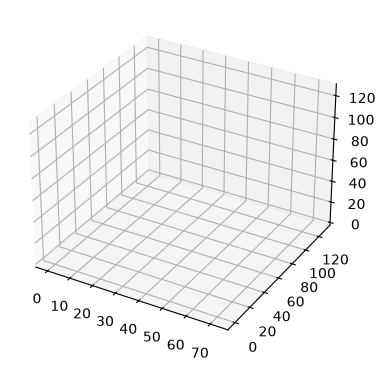

In [131]:


visualize_3d_masks(
    b.permute(1, 0, 2, 3),
    class_names=("Class 1", "Class 2", "Class 3"),
    step=2,
)

In [55]:
from torchvision import transforms
dataset = BaseModelDataset(Path('data/extracted_data/train/case2/case2_day1/scans'), transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(256)
            ]))
len(dataset)

144

In [56]:
dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 0)

In [27]:
from pathlib import Path
import numpy as np


def check_mask_files(
    mask_dir: Path,
    expected_shape=None,
    expected_dtype=None,
    check_values=True,
):
    """
    Validate every mask file directly inside mask_dir.

    The validation matches the way masks are loaded in the dataset:
        np.load(path, allow_pickle=False)['arr_0']

    Parameters
    ----------
    mask_dir : Path
        Directory containing mask files.

    expected_shape : tuple or None
        Expected shape, e.g. (3, 256, 256).
        If None, shape is not checked.

    expected_dtype : np.dtype or None
        Expected dtype, e.g. np.uint8.
        If None, dtype is not checked.

    check_values : bool
        If True, verify that the mask contains only 0 and 1.

    Returns
    -------
    valid_files : list[Path]
    invalid_files : list[tuple[Path, str]]
    """

    valid_files = []
    invalid_files = []

    for mask_path in sorted(mask_dir.iterdir()):

        # Ignore directories
        if not mask_path.is_file():
            continue

        try:
            # This is deliberately the same operation as in __getitem__
            with np.load(mask_path, allow_pickle=False) as data:

                # Check that the expected array exists
                if "arr_0" not in data.files:
                    raise ValueError(
                        f"'arr_0' not found. Available arrays: {data.files}"
                    )

                mask = data["arr_0"]

            # Check that it is actually a NumPy array
            if not isinstance(mask, np.ndarray):
                raise TypeError(
                    f"Expected ndarray, got {type(mask).__name__}"
                )

            # Shape check
            if expected_shape is not None:
                if mask.shape != expected_shape:
                    raise ValueError(
                        f"Wrong shape: {mask.shape}, "
                        f"expected {expected_shape}"
                    )

            # Dtype check
            if expected_dtype is not None:
                if mask.dtype != expected_dtype:
                    raise ValueError(
                        f"Wrong dtype: {mask.dtype}, "
                        f"expected {expected_dtype}"
                    )

           
            valid_files.append(mask_path)

        except Exception as e:
            invalid_files.append((mask_path, str(e)))

            print(
                f"[INVALID] {mask_path.name}\n"
                f"          {type(e).__name__}: {e}"
            )

    print("\n" + "=" * 70)
    print("MASK VALIDATION FINISHED")
    print("=" * 70)
    print(f"Total files : {len(valid_files) + len(invalid_files)}")
    print(f"Valid files : {len(valid_files)}")
    print(f"Invalid     : {len(invalid_files)}")

    if invalid_files:
        print("\nInvalid files:")
        for path, error in invalid_files:
            print(f"  {path}")
            print(f"      {error}")

    return valid_files, invalid_files

In [28]:
a = check_mask_files(
    Path('data/preprocessed_data/final_data/post_model/collapsed_mask')
)


MASK VALIDATION FINISHED
Total files : 274
Valid files : 274
Invalid     : 0


In [29]:
b = check_mask_files(
    Path('data/preprocessed_data/final_data/post_model/model_mask')
)

[INVALID] 263_149_130.npz
          ValueError: This file contains pickled (object) data. If you trust the file you can load it unsafely using the `allow_pickle=` keyword argument or `pickle.load()`.

MASK VALIDATION FINISHED
Total files : 38496
Valid files : 38495
Invalid     : 1

Invalid files:
  data\preprocessed_data\final_data\post_model\model_mask\263_149_130.npz
      This file contains pickled (object) data. If you trust the file you can load it unsafely using the `allow_pickle=` keyword argument or `pickle.load()`.


In [30]:
c =check_mask_files(
    Path('data/preprocessed_data/final_data/post_model/out_transformed_mask')
)



MASK VALIDATION FINISHED
Total files : 38496
Valid files : 38496
Invalid     : 0


In [26]:
len(c[1])

0

In [31]:
import pandas as pd
df = pd.read_csv('data_csv/train_post_model_kaggle.csv')


In [40]:
df[(df['slice'] == 130) & (df['collapsed_id'] == 263)]

,collapsed_id,case,slice,empty_slice,path,prev_path,next_path,mask_path,collapsed_mask_path,model_mask_path,out_transformed_mask_path
33729,263,149,130,True,/kaggle/input/datasets/vitaliilavryk/mri-segme...,/kaggle/input/datasets/vitaliilavryk/mri-segme...,/kaggle/input/datasets/vitaliilavryk/mri-segme...,/kaggle/input/datasets/vitaliilavryk/mri-segme...,/kaggle/input/datasets/vitaliilavryk/correctio...,/kaggle/input/datasets/vitaliilavryk/correctio...,/kaggle/input/datasets/vitaliilavryk/correctio...


In [41]:
df.iloc[33729]

collapsed_id                                                               263
case                                                                       149
slice                                                                      130
empty_slice                                                               True
path                         /kaggle/input/datasets/vitaliilavryk/mri-segme...
prev_path                    /kaggle/input/datasets/vitaliilavryk/mri-segme...
next_path                    /kaggle/input/datasets/vitaliilavryk/mri-segme...
mask_path                    /kaggle/input/datasets/vitaliilavryk/mri-segme...
collapsed_mask_path          /kaggle/input/datasets/vitaliilavryk/correctio...
model_mask_path              /kaggle/input/datasets/vitaliilavryk/correctio...
out_transformed_mask_path    /kaggle/input/datasets/vitaliilavryk/correctio...
Name: 33729, dtype: object

In [42]:
df = df.drop(33729)

In [105]:
df.model_mask_path.iloc[33729]

'/kaggle/input/datasets/vitaliilavryk/correction-mri-segmentation-dataset/preprocessed_data/final_data/post_model/model_mask/263_149_131.npz'

In [44]:
df.to_csv('data_csv/train_post_model_kaggle.csv')